# Hierarchical Forecasting Across Items — `HierarchicalBayesTimeSeries`

`HierarchicalBayesTimeSeries` extends `BayesTimeSeries` to multiple items at once. Every item has its own intercept, trend slope, seasonality coefficients, and event effects — but each per-item coefficient is **drawn from a population-level distribution** whose mean and spread are themselves learned from data. The items act like "individuals in a population"; pooling makes weak-signal items borrow strength from the rest.

Generative structure (in scaled [0, 1] space):

$$
\begin{aligned}
\mu_\alpha, \sigma_\alpha &\sim \text{hyper-priors} \quad\text{(intercept population)} \\
\alpha_i &\sim \mathcal{N}(\mu_\alpha, \sigma_\alpha) \quad\text{per item } i \\
\mu_\gamma, \sigma_\gamma &\sim \text{hyper-priors} \quad\text{(growth population)} \\
\gamma_i &\sim \mathcal{N}(\mu_\gamma, \sigma_\gamma) \\
\mu_{\beta,k}, \sigma_{\beta,k} &\sim \text{hyper-priors per Fourier feature } k \\
\beta_{i,k} &\sim \mathcal{N}(\mu_{\beta,k}, \sigma_{\beta,k}) \\
y_{t,i} &\sim \mathcal{N}(\alpha_i + \gamma_i t + \sum_k \beta_{i,k}\,\phi_{t,k} + \text{events}_{t,i}, \, \sigma)
\end{aligned}
$$

**Why this helps**: items with short or noisy histories get shrunk toward the population mean — partial pooling. Items with strong, distinctive signals stay close to their own MLE.

**Input format**: wide-format DataFrame — one `date` column plus one numeric column per item. Items are auto-detected as the non-date columns.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import arviz as az

from optistock.forecasting import (
    HierarchicalBayesTimeSeries,
    HierarchicalBayesTimeSeriesPriors,
    BayesTimeSeries,
    Prior,
)
from optistock.forecasting.base import ErrorEstimations

np.random.seed(42)

## Synthetic dataset — 8 items, deliberately uneven information

Eight items, all sharing a weekly + yearly seasonal pattern at the *population* level, but with item-specific magnitudes drawn from that population. Critically, **items 5–7 are "new SKUs"** — only their most recent 90 days of training history exist; everything before that is `NaN`. This is the realistic case that motivates hierarchical pooling: a freshly introduced product has barely any signal of its own, so the model has to lean on the population-level posterior learned from the long-history items to forecast it.

The hierarchical model handles the ragged panel by flattening to a 1-D vector of observed `(time, item)` cells; missing cells simply don't contribute to the likelihood. Short-history items still see the population posterior through the shared hyper-priors. The flat per-item baseline can't pool at all — we drop the NaN rows before fitting each short-history item independently, which is exactly what you'd be forced to do without a hierarchical structure.

Train shape: (495, 9)   Test shape: (45, 9)
Observed cells per item (train):
item_0    495
item_1    495
item_2    495
item_3    495
item_4    495
item_5     90
item_6     90
item_7     90


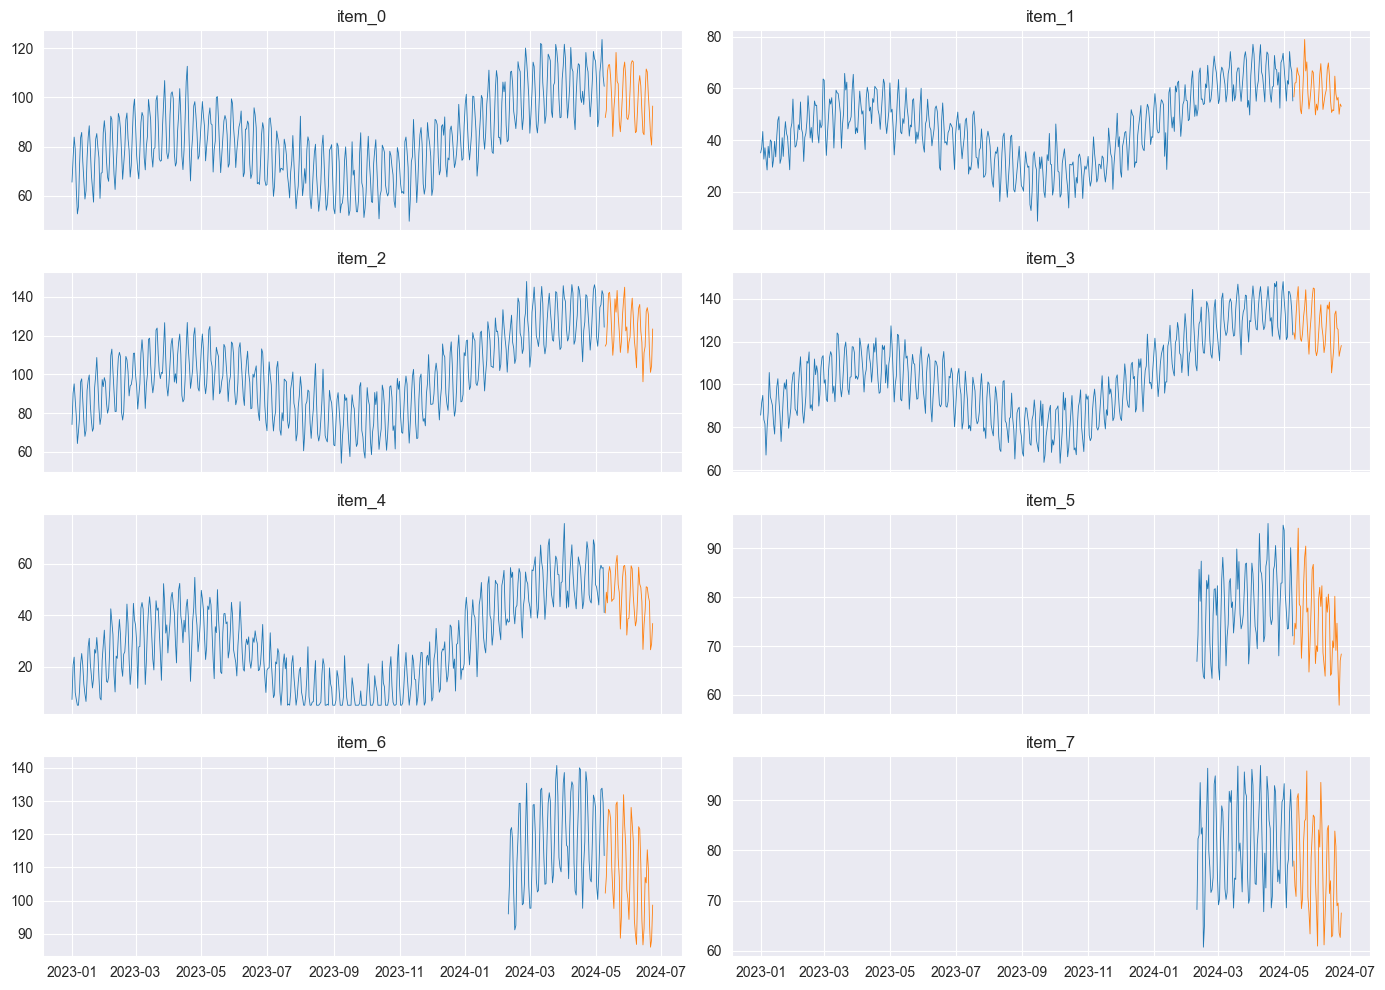

In [2]:
N = 540
dates = pd.date_range("2023-01-01", periods=N, freq="D")
t = np.arange(N)

# Population-level truth
true_intercept_mu, true_intercept_sigma = 60.0, 25.0
true_growth_mu,    true_growth_sigma    = 0.05, 0.02
true_weekly_amp_mu, true_weekly_amp_sd  = 12.0, 4.0
true_yearly_amp_mu, true_yearly_amp_sd  = 18.0, 6.0

n_items = 8
item_names = [f"item_{i}" for i in range(n_items)]

rng = np.random.default_rng(42)
alpha  = rng.normal(true_intercept_mu, true_intercept_sigma, n_items)
gamma  = rng.normal(true_growth_mu,    true_growth_sigma,    n_items)
w_amp  = np.abs(rng.normal(true_weekly_amp_mu, true_weekly_amp_sd, n_items))
y_amp  = np.abs(rng.normal(true_yearly_amp_mu, true_yearly_amp_sd, n_items))

sales = {}
for i, name in enumerate(item_names):
    series = (alpha[i] + gamma[i] * t
              + w_amp[i] * np.sin(2 * np.pi * t / 7)
              + y_amp[i] * np.sin(2 * np.pi * t / 365.25)
              + rng.normal(0, 4, N))
    sales[name] = np.maximum(series, 5).round(2)

df = pd.DataFrame({"date": dates, **sales})

# Hold out the last 45 days for evaluation
df_train = df.iloc[:-45].copy()
df_test  = df.iloc[-45:].copy()

# Items 5-7 are "new SKUs": only the most recent 90 days of training history
# exist; everything before that is NaN. The hierarchical model auto-imputes
# these cells and lets the short-history items borrow strength from items 0-4.
short_history_items = ["item_5", "item_6", "item_7"]
for name in short_history_items:
    df_train.loc[df_train.index[:-90], name] = np.nan

print("Train shape:", df_train.shape, "  Test shape:", df_test.shape)
print("Observed cells per item (train):")
print(df_train[item_names].notna().sum().to_string())

fig, axes = plt.subplots(4, 2, figsize=(14, 10), sharex=True)
for ax, name in zip(axes.flat, item_names):
    ax.plot(df_train["date"], df_train[name], lw=0.6, color="tab:blue")
    ax.plot(df_test["date"],  df_test[name],  lw=0.6, color="tab:orange")
    ax.set_title(name)
plt.tight_layout()

## Fit the hierarchical model

Defaults are tuned for partial pooling on small panels: per-item coefficients live in scaled [0, 1] space, and the hyper-`sigma`s are moderately tight `HalfNormal`s (0.3 for intercept/Fourier/event, 0.05 for growth). With only 8 items the population spread is weakly identified, so wide hyper-priors give the sampler funnel-shaped posteriors. You can still override any individual prior via `HierarchicalBayesTimeSeriesPriors(...)`.

**Scaling**: data is min-max scaled by a *single global maximum* (across all items and times). That keeps per-item coefficients on a common scale, which is what the shared hyper-priors implicitly assume. Per-item scaling would make a "scaled coefficient of 0.1" mean different real magnitudes per item and break the pooling.

**Ragged panels (new SKUs)**: NaN cells are dropped from the likelihood rather than imputed. The model still pools across items via the hyper-posterior, so short-history items borrow strength from the long-history ones — we just don't waste HMC budget on counterfactual past observations.

In [3]:
seasonal_config = {"weekly": (7, 3), "yearly": (365.25, 4)}

hier = HierarchicalBayesTimeSeries(df_train, seasonal_config=seasonal_config)
print(hier.priors)

idata_hier = hier.fit(chains=2, samples=1000)

HierarchicalBayesTimeSeriesPriors:
Variable            Distribution  Parameters          Description
-----------------------------------------------------------------
intercept_mu        Normal        mu=0.5, sigma=0.5   Population mean of per-item baseline level
intercept_sigma     HalfNormal    sigma=0.3           Population spread of per-item baseline level
growth_mu           Normal        mu=0.0, sigma=0.05  Population mean of per-item trend slope
growth_sigma        HalfNormal    sigma=0.05          Population spread of per-item trend slope
beta_fourier_mu     Normal        mu=0.0, sigma=0.3   Population mean of per-item Fourier coefficients (per feature)
beta_fourier_sigma  HalfNormal    sigma=0.3           Population spread of per-item Fourier coefficients (per feature)
beta_event_mu       Normal        mu=0.0, sigma=0.3   Population mean of per-item event effect (per event)
beta_event_sigma    HalfNormal    sigma=0.3           Population spread of per-item event effect (per ev

Initializing NUTS using jitter+adapt_diag...
c:\Users\bouwe\OneDrive\Desktop\GitCode\OptiStock\.venv\Lib\site-packages\pytensor\link\c\cmodule.py:2986: UserWarning: PyTensor could not link to a BLAS installation. Operations that might benefit from BLAS will be severely degraded.
This usually happens when PyTensor is installed via pip. We recommend it be installed via conda/mamba/pixi instead.
Alternatively, you can use an experimental backend such as Numba or JAX that perform their own BLAS optimizations, by setting `pytensor.config.mode == 'NUMBA'` or passing `mode='NUMBA'` when compiling a PyTensor function.
For more options and details see https://pytensor.readthedocs.io/en/latest/troubleshooting.html#how-do-i-configure-test-my-blas-library
  warnings.warn(
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [intercept_mu, intercept_sigma, growth_mu, growth_sigma, beta_fourier_mu, beta_fourier_sigma, beta_event_mu, beta_event_sigma, z_intercept, z_growth, z_beta_fourier, z_beta_event, 

Output()

Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 339 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
Sampling: [y]


Output()

## Baseline: fit each item independently with `BayesTimeSeries`

For comparison, fit one flat model per item. This is what you'd do without pooling — every item has independent priors and no information flows between them. We expect the hierarchical model to do better on the noisy items (5–7) because those items can borrow strength from the well-identified ones.

In [4]:
flat_models = {}
for name in item_names:
    df_i = (df_train[["date", name]]
            .dropna(subset=[name])              # flat model can't handle NaN history
            .rename(columns={name: "sales"}))
    m = BayesTimeSeries(df_i, seasonal_config=seasonal_config)
    m.fit(target="sales", date_col="date", chains=2, samples=1000)
    flat_models[name] = m

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [intercept, growth, beta_event, beta_fourier, sigma]


Output()

Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 14 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
Sampling: [y]


Output()

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [intercept, growth, beta_event, beta_fourier, sigma]


...

Output()

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [intercept, growth, beta_event, beta_fourier, sigma]


Output()

Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 107 seconds.
Chain 0 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
Chain 1 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
Sampling: [y]


Output()

## Inspect the population-level (hyper) posteriors

These are the new pieces compared to the flat model. The means tell you the population-typical value of each coefficient; the sigmas tell you how much items differ from each other. They are the *only* parameters that pool information across items.

In [13]:
summary = az.summary(
    idata_hier,
    var_names=["intercept_mu", "intercept_sigma",
               "growth_mu",    "growth_sigma",
               "beta_fourier_mu", "beta_fourier_sigma",
               "sigma"],
    hdi_prob=0.94, round_to=3,
)
print(summary)

                                   mean     sd  hdi_3%  hdi_97%  mcse_mean  \
intercept_mu                      0.380  0.070   0.256    0.514      0.003   
intercept_sigma                   0.195  0.062   0.106    0.310      0.002   
growth_mu                         0.000  0.000   0.000    0.000      0.000   
growth_sigma                      0.000  0.000   0.000    0.000      0.000   
beta_fourier_mu[weekly_sin_1]     0.082  0.009   0.065    0.099      0.000   
beta_fourier_mu[weekly_cos_1]    -0.001  0.001  -0.004    0.002      0.000   
beta_fourier_mu[weekly_sin_2]    -0.000  0.001  -0.002    0.001      0.000   
beta_fourier_mu[weekly_cos_2]    -0.000  0.001  -0.002    0.002      0.000   
beta_fourier_mu[weekly_sin_3]     0.001  0.001  -0.001    0.003      0.000   
beta_fourier_mu[weekly_cos_3]    -0.001  0.001  -0.003    0.001      0.000   
beta_fourier_mu[yearly_sin_1]     0.120  0.015   0.091    0.148      0.001   
beta_fourier_mu[yearly_cos_1]    -0.000  0.001  -0.002    0.002 

## Per-item intercept shrinkage

Classic hierarchical-model diagnostic: plot each item's intercept under both models. The hierarchical estimates should be **pulled toward the population mean**, with the strongest pull on noisy items (5, 6, 7).

Note that intercepts here are in the model's scaled [0, 1] space — multiply by the item's max_scaler to recover original sales units.

  item  flat_intercept  hier_intercept  shrinkage
item_0          67.450          67.420      0.029
item_1          33.379          33.430     -0.051
item_2          78.879          78.852      0.027
item_3          82.523          82.551     -0.028
item_4          12.214          12.196      0.018
item_5          86.152          41.727     44.425
item_6          81.182          69.789     11.392
item_7          69.956          56.088     13.868


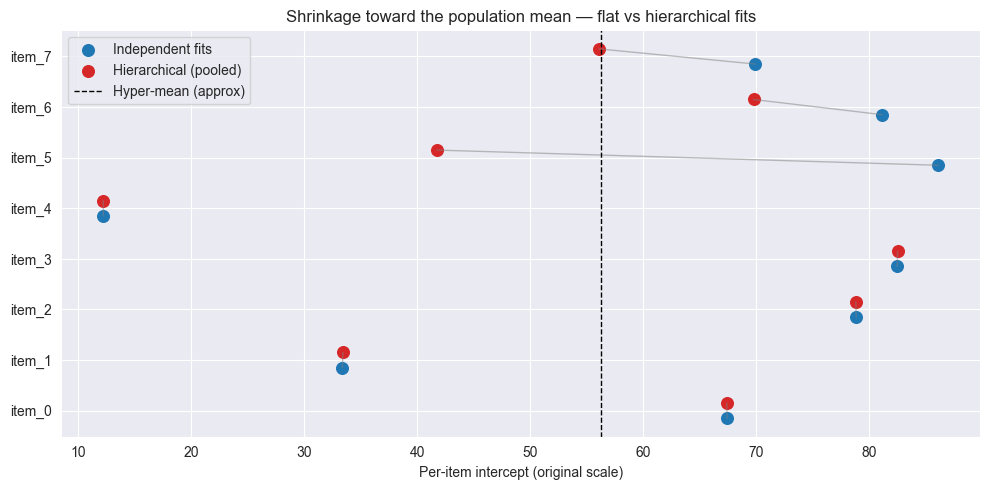

In [14]:
rows = []
for name in item_names:
    flat_alpha = flat_models[name].idata.posterior["intercept"].mean().item()
    scaler_flat = flat_models[name].max_scaler
    flat_alpha_orig = flat_alpha * scaler_flat

    hier_alpha = idata_hier.posterior["intercept"].sel(item=name).mean().item()
    hier_alpha_orig = hier_alpha * hier.max_scaler
    rows.append((name, flat_alpha_orig, hier_alpha_orig))

pop_mean = idata_hier.posterior["intercept_mu"].mean().item() * hier.max_scaler

tbl = pd.DataFrame(rows, columns=["item", "flat_intercept", "hier_intercept"])
tbl["shrinkage"] = tbl["flat_intercept"] - tbl["hier_intercept"]
print(tbl.round(3).to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 5))
y = np.arange(len(item_names))
ax.scatter(tbl["flat_intercept"], y - 0.15, color="tab:blue", s=70, label="Independent fits")
ax.scatter(tbl["hier_intercept"], y + 0.15, color="tab:red",  s=70, label="Hierarchical (pooled)")
for i in range(len(item_names)):
    ax.plot([tbl["flat_intercept"].iloc[i], tbl["hier_intercept"].iloc[i]],
            [y[i] - 0.15, y[i] + 0.15], color="gray", alpha=0.5, lw=1)
ax.axvline(pop_mean, ls="--", color="black", lw=1, label="Hyper-mean (approx)")
ax.set_yticks(y)
ax.set_yticklabels(item_names)
ax.set_xlabel("Per-item intercept (original scale)")
ax.set_title("Shrinkage toward the population mean — flat vs hierarchical fits")
ax.legend()
plt.tight_layout()

## Holdout forecast — all items at once

`forecast` returns posterior predictive samples for every item in one call. `plot_forecast()` lays them out as a grid; `plot_forecast(item=...)` zooms to one. SMAPE is computed per item and averaged across the noisy and well-identified subgroups separately — that's where you should see the pooling pay off.

In [15]:
df_future = pd.DataFrame({"date": df_test["date"].values})
fc_hier = hier.forecast(scenario={"df_future": df_future.copy()})

# Also forecast each flat model
fc_flat = {}
for name in item_names:
    fc_flat[name] = flat_models[name].forecast(
        scenario={"df_future": df_future.copy(), "date_col": "date"}
    )

smape = ErrorEstimations.calculate_smape
rows = []
for name in item_names:
    actual = df_test[name].values
    flat_mean = (fc_flat[name].predictions["y"].mean(dim=("chain","draw")).values
                 * flat_models[name].max_scaler)
    hier_mean = (fc_hier.predictions["y"].sel(item=name).mean(dim=("chain","draw")).values
                 * hier.max_scaler)
    rows.append((name, smape(actual, flat_mean), smape(actual, hier_mean)))

smape_df = pd.DataFrame(rows, columns=["item", "flat_smape", "hier_smape"])
smape_df["improvement_pp"] = smape_df["flat_smape"] - smape_df["hier_smape"]
print(smape_df.round(2).to_string(index=False))

noisy = smape_df[smape_df["item"].isin(["item_5","item_6","item_7"])]
clean = smape_df[~smape_df["item"].isin(["item_5","item_6","item_7"])]
print(f"\nNoisy items (5,6,7) mean SMAPE: flat={noisy['flat_smape'].mean():.2f}%  hier={noisy['hier_smape'].mean():.2f}%")
print(f"Clean items (0-4)   mean SMAPE: flat={clean['flat_smape'].mean():.2f}%  hier={clean['hier_smape'].mean():.2f}%")

Sampling: [y]


Output()

Sampling: [y]


Output()

Sampling: [y]


...

Sampling: [y]


Output()

Sampling: [y]


Output()

  item  flat_smape  hier_smape  improvement_pp
item_0        2.80        2.78            0.02
item_1        5.12        5.22           -0.10
item_2        2.51        2.57           -0.06
item_3        2.61        2.59            0.01
item_4        7.18        7.21           -0.03
item_5      128.80        4.55          124.25
item_6       34.12        4.44           29.69
item_7       13.57        4.76            8.81

Noisy items (5,6,7) mean SMAPE: flat=58.83%  hier=4.58%
Clean items (0-4)   mean SMAPE: flat=4.04%  hier=4.08%


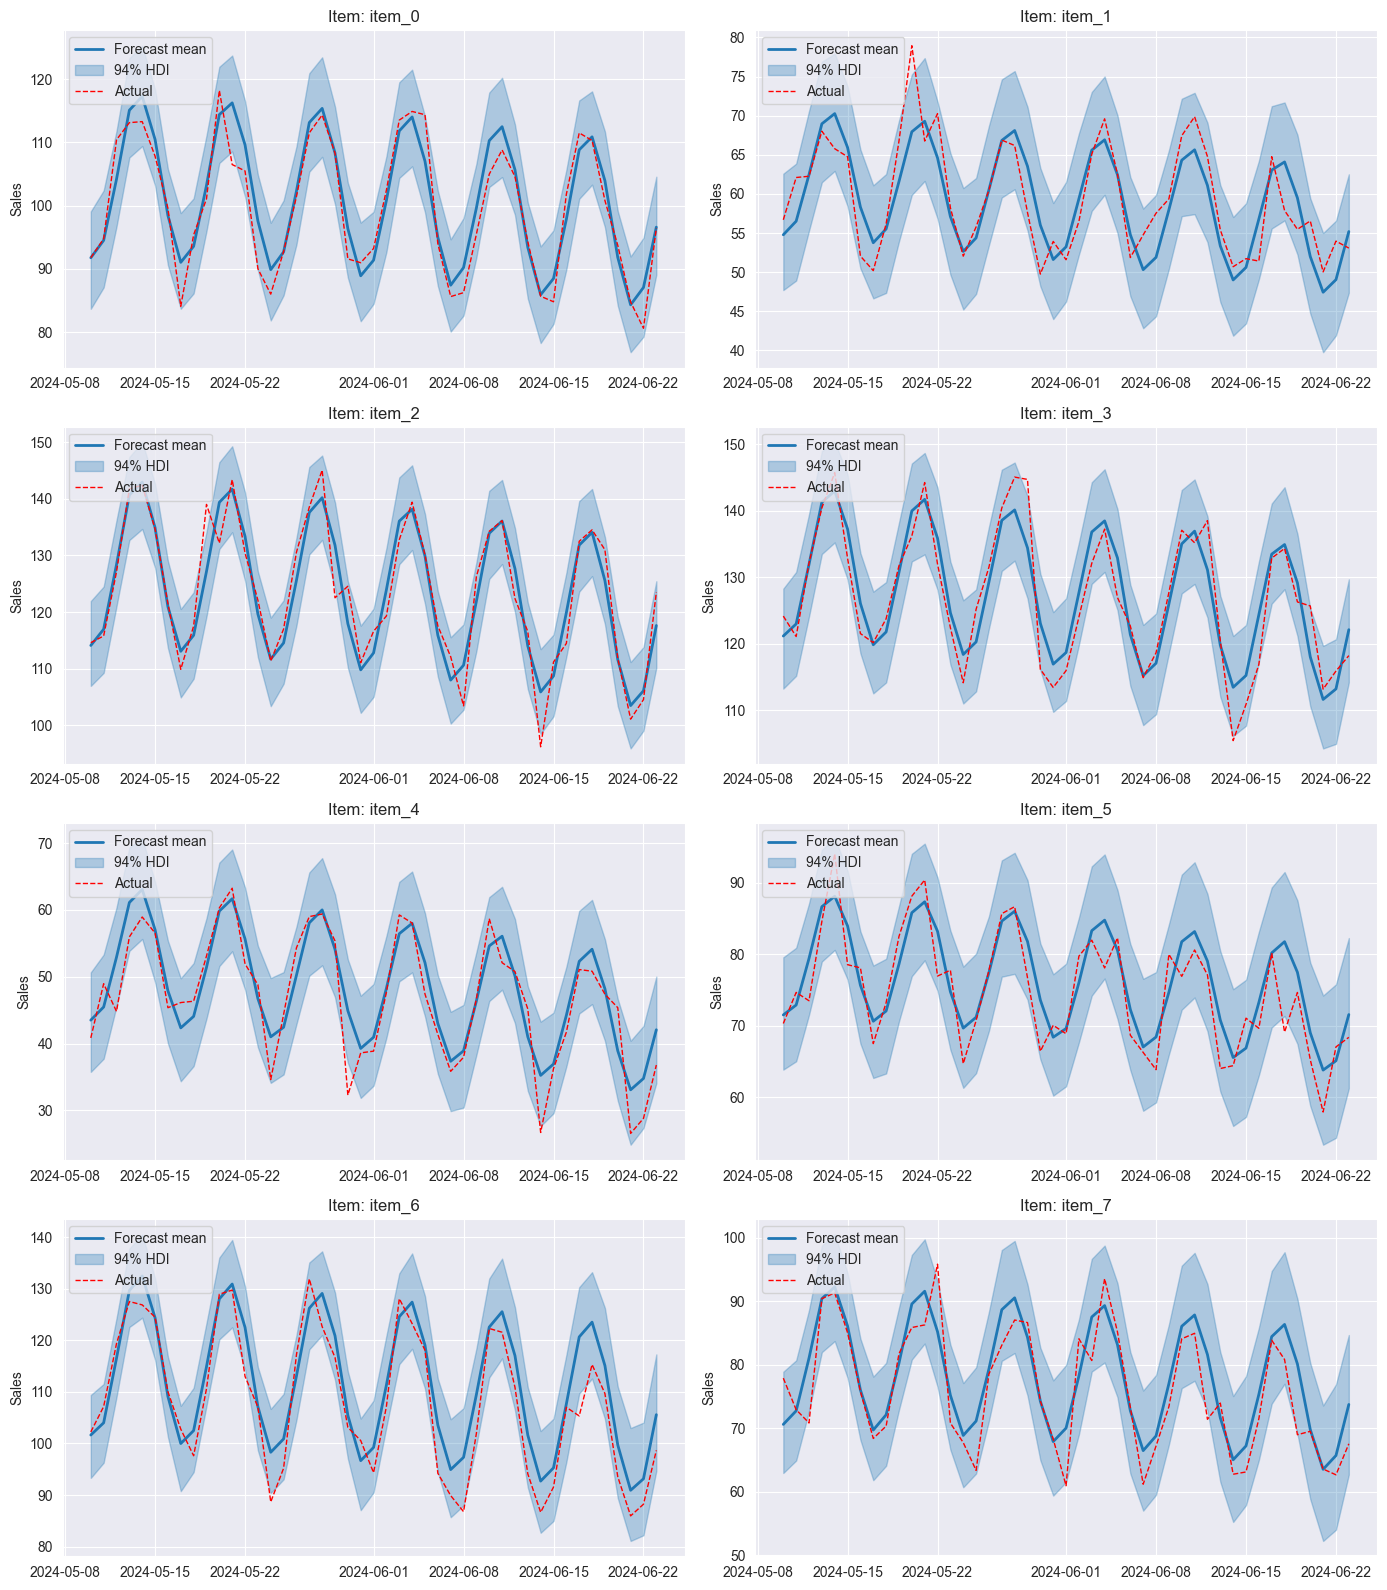

In [16]:
fig, axes = hier.plot_forecast()
for ax, name in zip(axes.flat, item_names):
    ax.plot(df_test["date"], df_test[name], "r--", lw=1, label="Actual")
    ax.legend(loc="upper left")

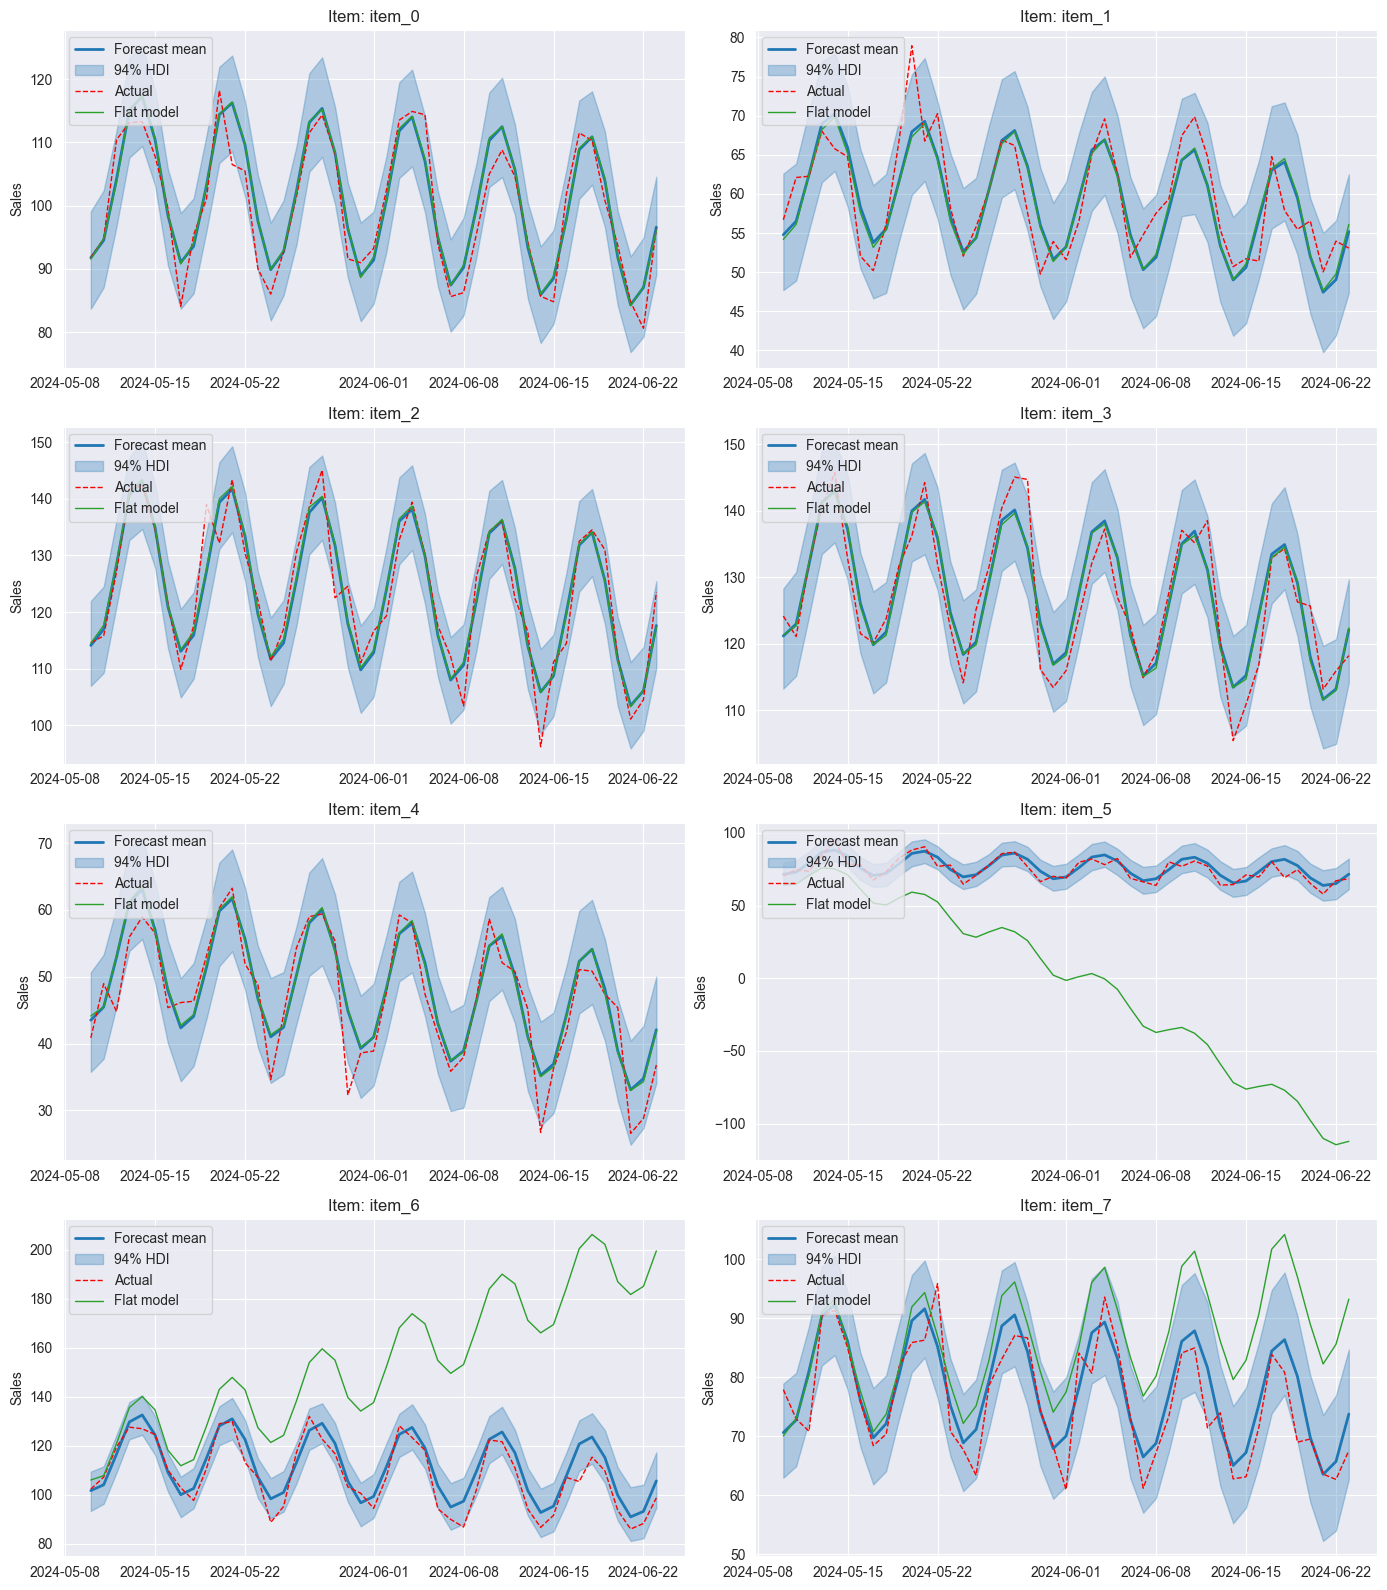

In [17]:
for ax, name in zip(axes.flat, item_names):
    flat_mean = (fc_flat[name].predictions["y"].mean(dim=("chain", "draw")).values
                 * flat_models[name].max_scaler)
    ax.plot(df_test["date"], flat_mean, color="tab:green", lw=1, label="Flat model")
    ax.legend(loc="upper left")
fig

### Per-item component decomposition

Same decomposition as `BayesTimeSeries.plot_components()`, but each item is a separate posterior slice of the joint hierarchical fit.

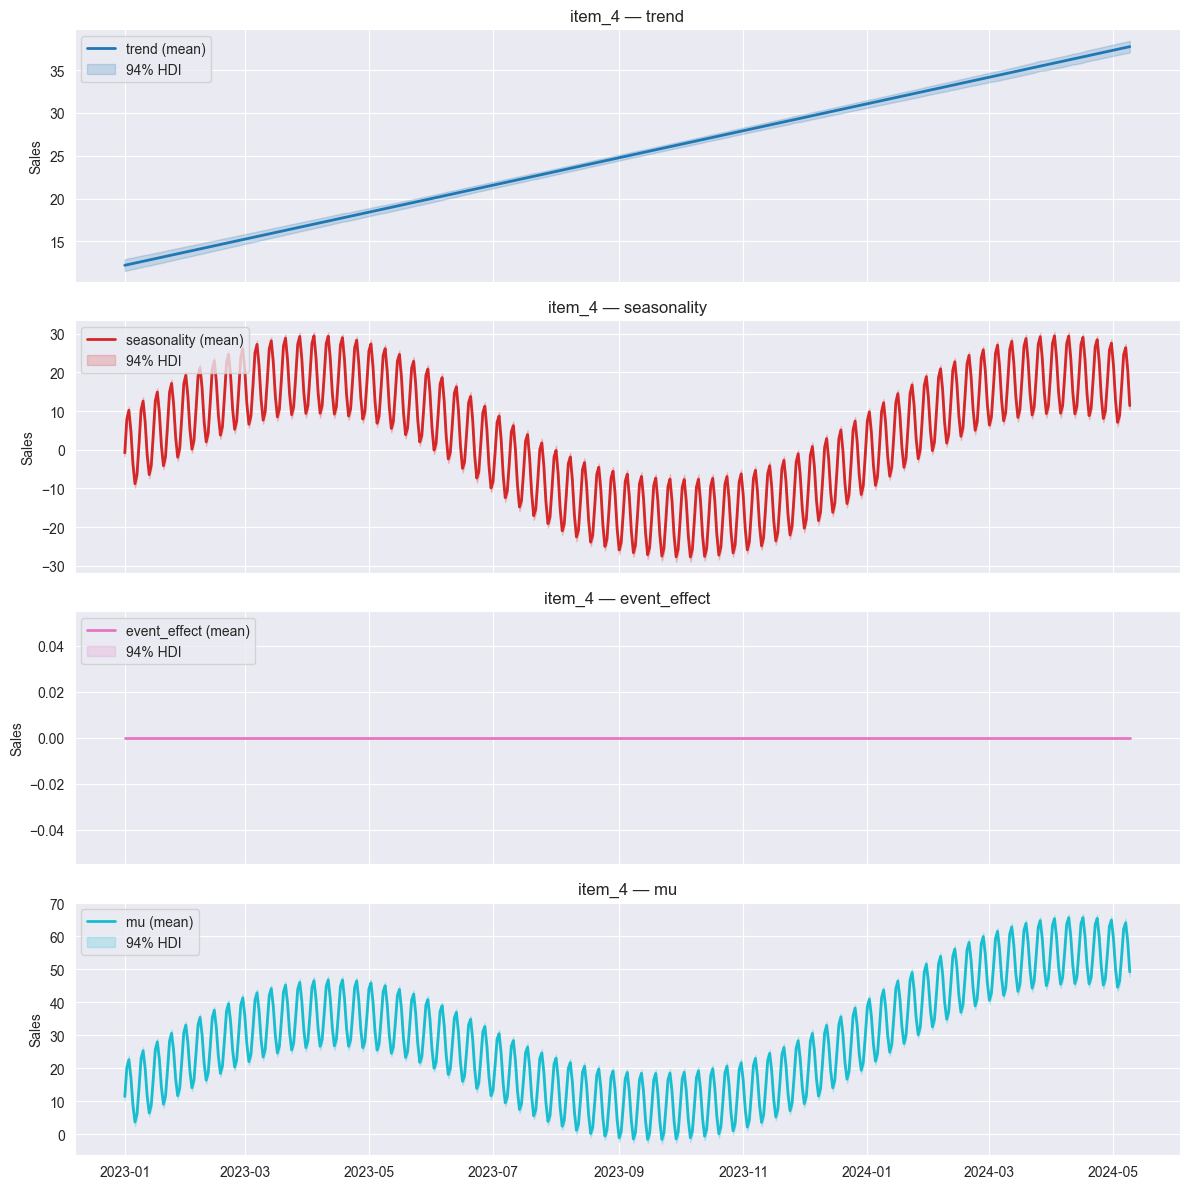

In [18]:
fig, axes = hier.plot_components(item="item_4")  # one of the noisy items

## Demand distributions for the planning horizon

`get_demand_distribution(start, end)` returns total demand per item across the window — a `Dataset` with an `item` dim. Pass `item=...` to get a single-item distribution in the same shape `BayesTimeSeries` returns, so it plugs straight into `ForecastSolver` one item at a time.

All-items distribution: {'chain': 2, 'draw': 1000, 'item': 8}


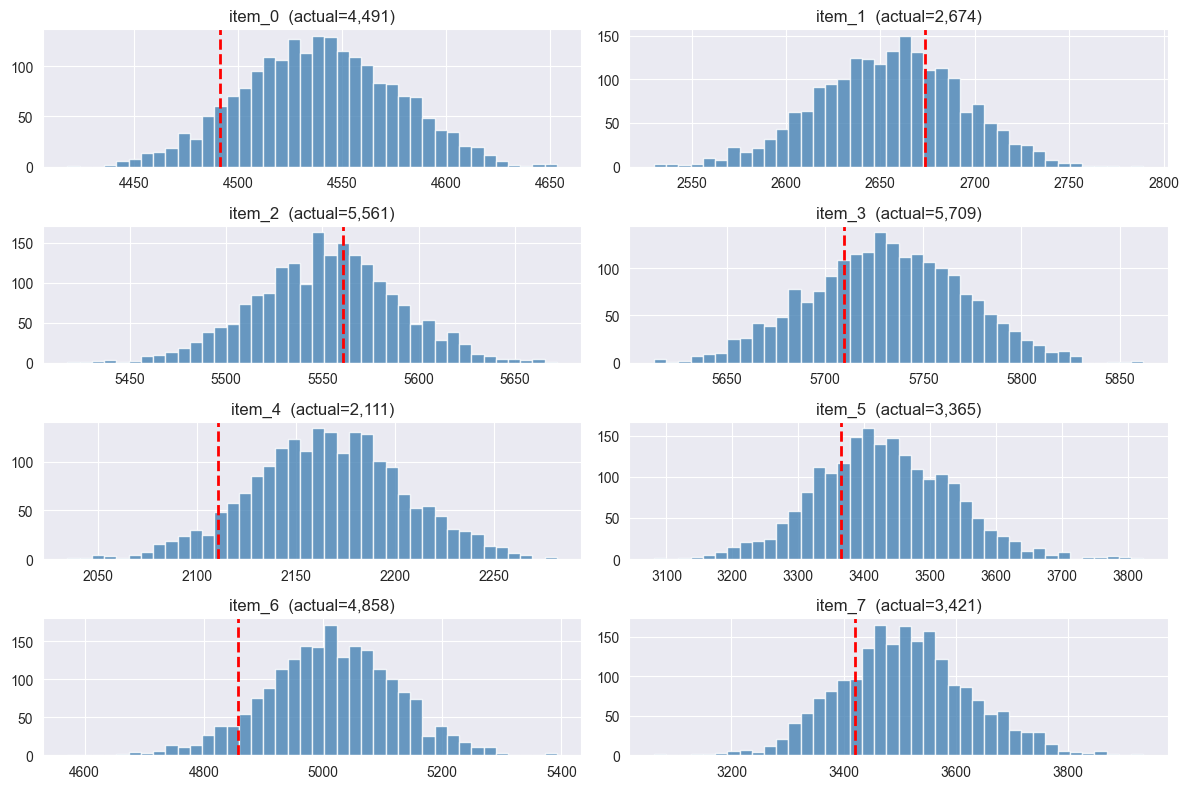

In [19]:
start, end = str(df_test["date"].iloc[0].date()), str(df_test["date"].iloc[-1].date())

dist_all = hier.get_demand_distribution(start, end)
print("All-items distribution:", dict(dist_all.demand.sizes))

fig, axes = plt.subplots(4, 2, figsize=(12, 8), sharex=False)
for ax, name in zip(axes.flat, item_names):
    samples = dist_all.demand.sel(item=name).values.flatten()
    actual_total = df_test[name].sum()
    ax.hist(samples, bins=40, color="steelblue", edgecolor="white", alpha=0.8)
    ax.axvline(actual_total, color="red", linestyle="--", lw=2)
    ax.set_title(f"{name}  (actual={actual_total:,.0f})")
plt.tight_layout()

## Customising the hyper-priors

Every hyper-prior is a regular `Prior` and can be swapped out. For example, if you have strong prior belief that items don't differ much in baseline level — say you're forecasting near-identical SKUs — tighten `intercept_sigma`:

In [20]:
tight_priors = HierarchicalBayesTimeSeriesPriors(
    intercept_sigma=Prior("HalfNormal", {"sigma": 0.1},
                          "Tight pooling: items expected to share a similar baseline"),
    growth_sigma=Prior("HalfNormal", {"sigma": 0.05},
                       "Tight pooling: items expected to grow at similar rates"),
)
print(tight_priors)

HierarchicalBayesTimeSeriesPriors:
Variable            Distribution  Parameters          Description
-----------------------------------------------------------------
intercept_mu        Normal        mu=0.5, sigma=0.5   Population mean of per-item baseline level
intercept_sigma     HalfNormal    sigma=0.1           Tight pooling: items expected to share a similar baseline
growth_mu           Normal        mu=0.0, sigma=0.05  Population mean of per-item trend slope
growth_sigma        HalfNormal    sigma=0.05          Tight pooling: items expected to grow at similar rates
beta_fourier_mu     Normal        mu=0.0, sigma=0.3   Population mean of per-item Fourier coefficients (per feature)
beta_fourier_sigma  HalfNormal    sigma=0.3           Population spread of per-item Fourier coefficients (per feature)
beta_event_mu       Normal        mu=0.0, sigma=0.3   Population mean of per-item event effect (per event)
beta_event_sigma    HalfNormal    sigma=0.3           Population spread of per

## Takeaways

- **API**: same `fit → forecast → get_demand_distribution` pattern as `BayesTimeSeries`. The only structural changes are wide-format input and an optional `item` argument on the plotting / demand methods.
- **Pooling**: per-item coefficients are drawn from a population-level distribution learned from data. Noisy items shrink toward the population mean; well-identified items barely move.
- **Non-centered parameterisation** is used internally so HMC doesn't run into Neal's funnel on the hyper-sigmas. The `intercept`/`growth`/`beta_*` posteriors are stored as Deterministics for interpretability.
- **When pooling pays off**: heterogeneous histories (some items new, some old), noisy items, or sparse panels where you'd otherwise overfit on weak signals. When every item has a long, clean history the pooling pays roughly zero — but costs nothing either.